# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [8]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from keras.utils import to_categorical
from tensorflow.keras import layers, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [9]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

c:\Users\ghugo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [10]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [11]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# La incluimos para ayudarte con la identificación de clases. De ti depende
# si quieres utilizar esta variable o no
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [12]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

In [13]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponible: []


## Carga y preparación de CIFAR-10

In [14]:
# Carga del dataset CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Nombres de clases oficiales de CIFAR-10
class_names = [
    "avión", "automóvil", "pájaro", "gato", "ciervo",
    "perro", "rana", "caballo", "barco", "camión"
]

num_classes = len(class_names)

# Normalización a rango [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Etiquetas en formato vector 1D
y_train_full = y_train_full.reshape(-1)
y_test = y_test.reshape(-1)

# Split train/validación
validation_size = 10000

x_train = x_train_full[:-validation_size]
y_train = y_train_full[:-validation_size]

x_val = x_train_full[-validation_size:]
y_val = y_train_full[-validation_size:]

print("Train:", x_train.shape, y_train.shape)
print("Validación:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (40000, 32, 32, 3) (40000,)
Validación: (10000, 32, 32, 3) (10000,)
Test: (10000, 32, 32, 3) (10000,)


## Análisis inicial de clases

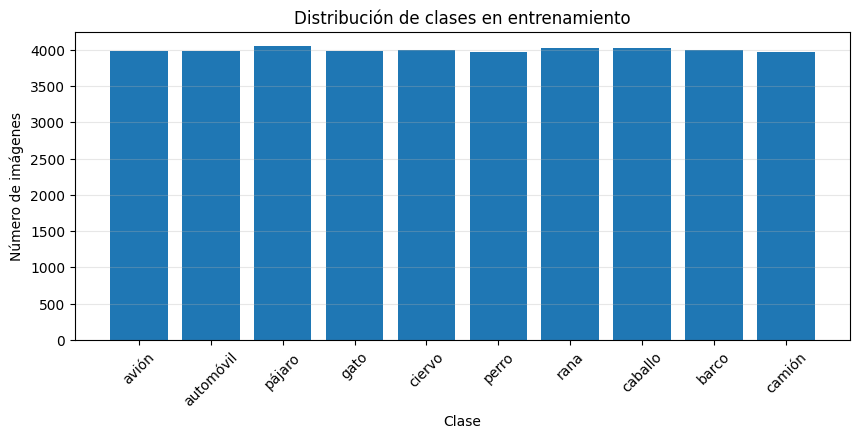

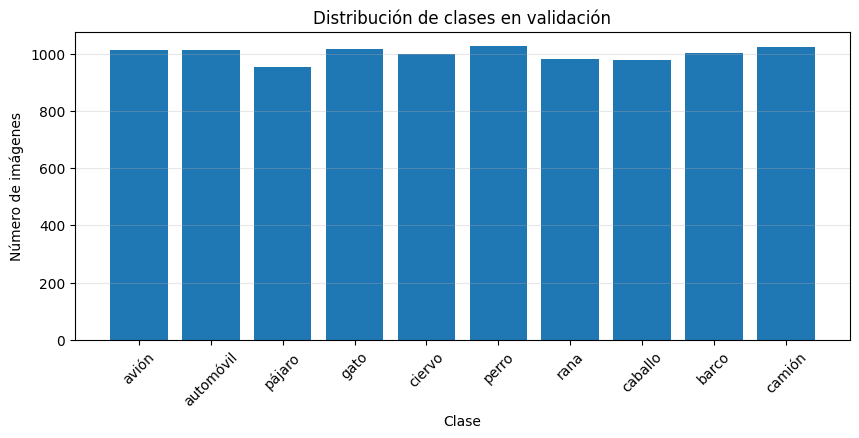

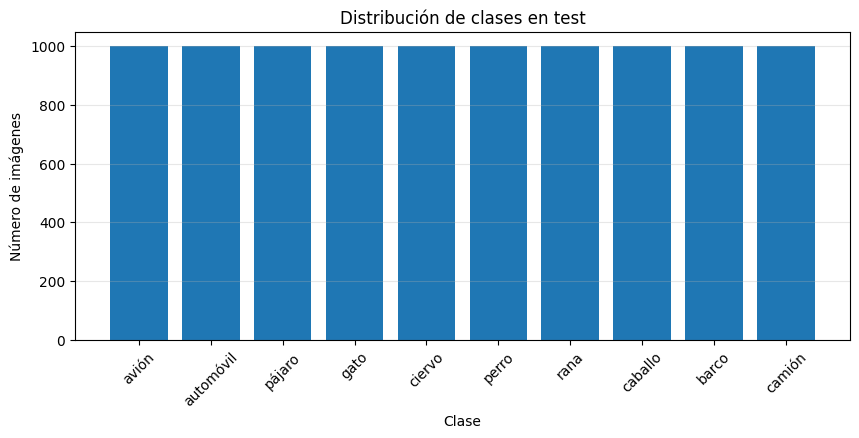

In [15]:
def plot_class_distribution(y, title):
    counts = pd.Series(y).value_counts().sort_index()
    
    plt.figure(figsize=(10, 4))
    plt.bar(class_names, counts.values)
    plt.title(title)
    plt.xlabel("Clase")
    plt.ylabel("Número de imágenes")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

plot_class_distribution(y_train, "Distribución de clases en entrenamiento")
plot_class_distribution(y_val, "Distribución de clases en validación")
plot_class_distribution(y_test, "Distribución de clases en test")

## Visualización de ejemplos

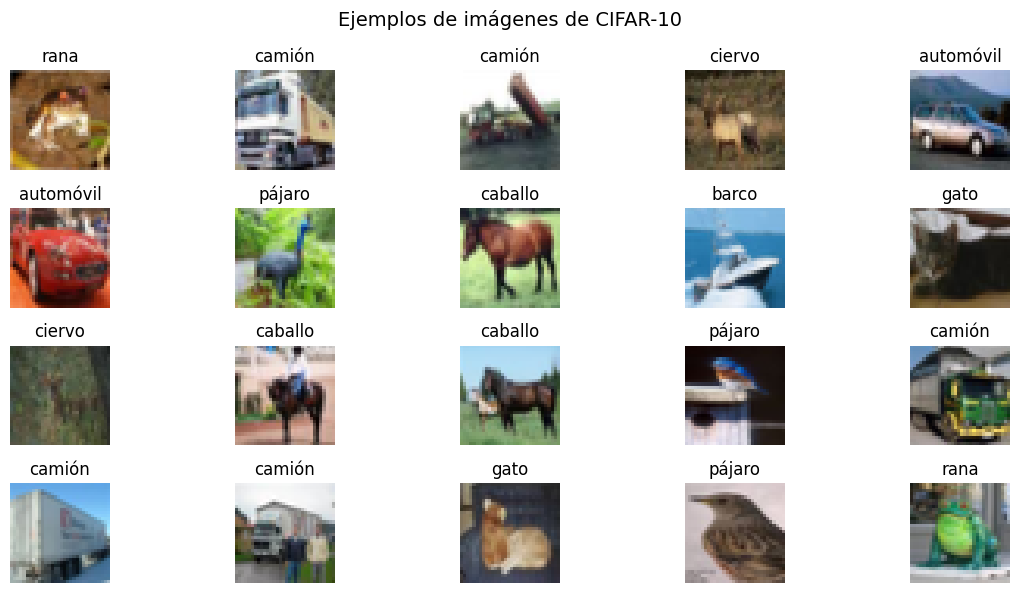

In [16]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Ejemplos de imágenes de CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()

## Funciones comunes de entrenamiento, evaluación y gráficas

In [ ]:
# ============================================================
# Protocolo experimental común
# ============================================================

SEED = 42
MAX_EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

experiment_results = []
histories = {}
trained_models = {}
predictions = {}


def reset_experiment(seed=SEED):
    """Reinicia semillas y limpia sesión para hacer los experimentos más reproducibles."""
    tf.keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def compile_model(model, learning_rate=LEARNING_RATE):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def get_common_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
    ]


def run_experiment(
    model_name,
    build_model_fn,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE
):
    """
    Ejecuta un experimento completo con el mismo protocolo para todos los modelos.
    El conjunto de test solo se evalúa al final.
    """
    reset_experiment(SEED)

    model = build_model_fn()
    model = compile_model(model, learning_rate=learning_rate)

    print(f"\nEntrenando modelo: {model_name}")
    model.summary()

    start_time = time.time()

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=get_common_callbacks(),
        verbose=1
    )

    fit_time = time.time() - start_time

    # Evaluación final con los mejores pesos restaurados por EarlyStopping.
    train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=0)
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    y_pred_proba = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result = {
        "modelo": model_name,
        "parametros": model.count_params(),
        "epochs_entrenadas": len(history.history["loss"]),
        "best_epoch": best_epoch,
        "tiempo_fit_seg": round(fit_time, 2),
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "max_epochs": max_epochs
    }

    experiment_results.append(result)
    histories[model_name] = history.history
    trained_models[model_name] = model
    predictions[model_name] = y_pred

    display(pd.DataFrame([result]).T)

    return model, history, y_pred


def plot_training_curves(model_name):
    h = histories[model_name]
    result = next(r for r in experiment_results if r["modelo"] == model_name)

    test_accuracy = result["test_accuracy"]
    test_loss = result["test_loss"]

    epochs_range = range(1, len(h["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, h["accuracy"], label="Train accuracy")
    plt.plot(epochs_range, h["val_accuracy"], label="Validation accuracy")
    plt.axhline(test_accuracy, linestyle="--", label="Final test accuracy")
    plt.title(f"Curva de accuracy - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, h["loss"], label="Train loss")
    plt.plot(epochs_range, h["val_loss"], label="Validation loss")
    plt.axhline(test_loss, linestyle="--", label="Final test loss")
    plt.title(f"Curva de pérdida - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def show_results_table():
    results_df = pd.DataFrame(experiment_results)
    results_df = results_df.sort_values("test_accuracy", ascending=False)

    cols = [
        "modelo",
        "parametros",
        "epochs_entrenadas",
        "best_epoch",
        "tiempo_fit_seg",
        "train_accuracy",
        "val_accuracy",
        "test_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "learning_rate",
        "batch_size"
    ]

    return results_df[cols]

## Modelo 0. Baseline MLP

Model: "M0_MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2377 - loss: 2.0627 - val_accuracy: 0.3272 - val_loss: 1.8911 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.2927 - loss: 1.9165 - val_accuracy: 0.3396 - val_loss: 1.8382 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.3117 - loss: 1.8760 - val_accuracy: 0.3374 - val_loss: 1.8479 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3207 - loss: 1.8477 - val_accuracy: 0.3571 - val_loss: 1.8023 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.3334 - loss: 1.8240 - val_accuracy: 0.3647 - val_loss: 1.7972 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3338 - loss: 1.8120 - val_accuracy: 0.3853 - val_loss: 1.7554 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.3434 - loss: 1

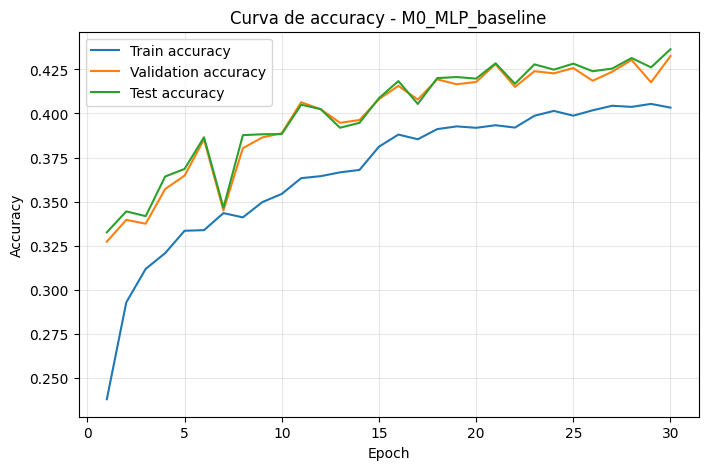

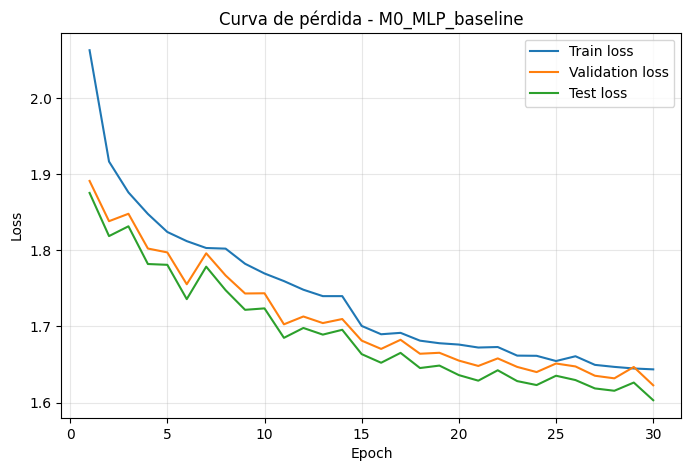

In [ ]:
def build_mlp_baseline():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ], name="M0_MLP_baseline")

    return model


mlp_model = build_mlp_baseline()
mlp_model.summary()

mlp_model, mlp_history, mlp_pred = run_experiment(
    model_name="M0_MLP_baseline",
    build_model_fn=build_mlp_baseline
)

plot_training_curves("M0_MLP_baseline")

### Análisis del modelo M0. MLP baseline

El modelo MLP obtiene una accuracy en test de aproximadamente 43.65 %, con un F1 macro de 0.428. Aunque el resultado es superior al azar, sigue siendo limitado para un problema de clasificación de imágenes como CIFAR-10.

La principal limitación del modelo es que aplana las imágenes mediante flatten, convirtiendo cada imagen de 32 × 32 × 3 en un vector unidimensional. Como consecuencia, se pierde la estructura espacial entre píxeles vecinos, que es especialmente relevante en visión por computador.

Las curvas de entrenamiento muestran una mejora progresiva tanto en accuracy como en pérdida. No se observa sobreajuste claro, ya que las métricas de validación y test son incluso ligeramente superiores a las de entrenamiento, esto puede explicarse por el uso de dropout.

En conclusión, este modelo sirvecomo línea base para comparar posteriormente con arquitecturas convolucionales, que deberían obtener mejores resultados al explotar patrones locales de la imagen mediante filtros.

## Modelo 1. CNN simple

Model: "M1_CNN_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.4198 - loss: 1.5857 - val_accuracy: 0.5559 - val_loss: 1.2318 - learning_rate: 0.0010
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.5849 - loss: 1.1709 - val_accuracy: 0.6498 - val_loss: 0.9962 - learning_rate: 0.0010
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.6553 - loss: 0.9847 - val_accuracy: 0.6846 - val_loss: 0.8994 - learning_rate: 0.0010
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.6979 - loss: 0.8599 - val_accuracy: 0.7106 - val_loss: 0.8405 - learning_rate: 0.0010
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7305 - loss: 0.7710 - val_accuracy: 0.7192 - val_loss: 0.8106 - learning_rate: 0.0010
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7567 - loss: 0.6932 - val_accuracy: 0.7222 - val_loss: 0.8013 - learning_rate: 0.0010
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.7765 - l

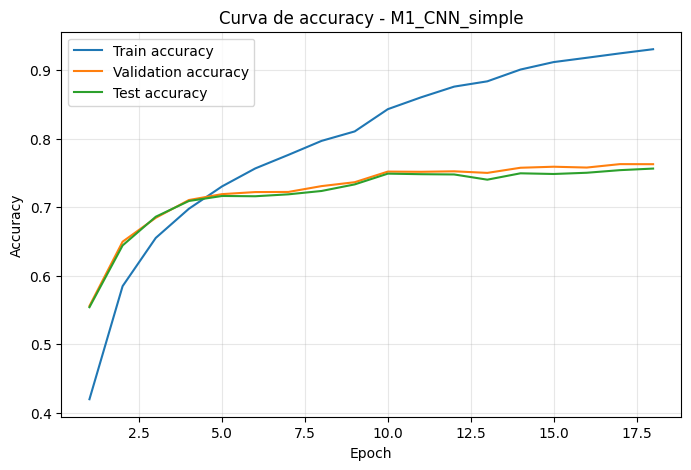

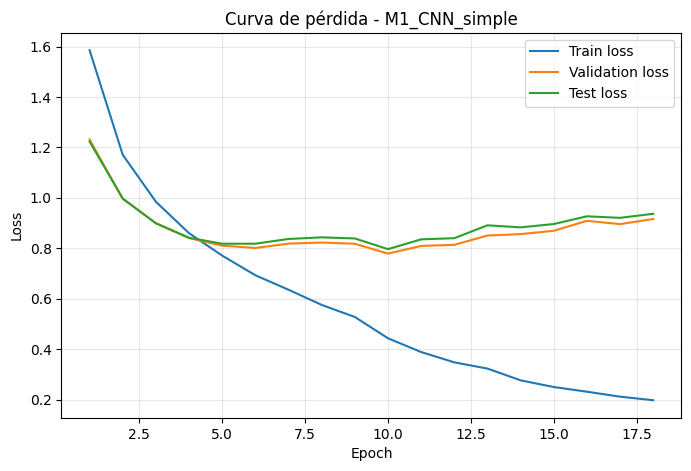

In [ ]:
def build_simple_cnn():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ], name="M1_CNN_simple")

    return model


simple_cnn = build_simple_cnn()
simple_cnn.summary()

simple_cnn, simple_cnn_history, simple_cnn_pred = run_experiment(
    model_name="M1_CNN_simple",
    build_model_fn=build_simple_cnn
)

plot_training_curves("M1_CNN_simple")

### Análisis del modelo M1. CNN simple

El modelo CNN simple mejora de forma muy significativa al baseline MLP. Mientras que el MLP obtiene una accuracy en test de 43.65 %, la CNN simple alcanza aproximadamente 74.91 %, utilizando además muchos menos parámetros. Esto confirma que las capas convolucionales son mucho más adecuadas para CIFAR-10, ya que pueden aprender patrones locales de las imágenes y conservar información espacial.

Sin embargo, las curvas muestran sobreajuste. A partir de las primeras epochs, la accuracy de entrenamiento sigue aumentando hasta superar el 90 %, mientras que las métricas de validación y test se estabilizan alrededor del 75 %. De forma similar, la pérdida de entrenamiento sigue bajando, pero la pérdida de validación/test deja de mejorar y empieza a aumentar.

Por tanto, este modelo demuestra la ventaja de las CNN frente a las redes fully connected, pero todavía necesita regularización adicional para combatir el sobreajuste. En los siguientes modelos se incorporarán técnicas como Batch Normalization, Dropout, regularización L2 y data augmentation para intentar mejorar la generalización.

## Celda M2. CNN regularizada

Model: "M2_CNN_BatchNorm_Dropout_L2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 109ms/step - accuracy: 0.4330 - loss: 1.7049 - val_accuracy: 0.3879 - val_loss: 1.9301 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.6034 - loss: 1.2169 - val_accuracy: 0.6483 - val_loss: 1.0952 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 106ms/step - accuracy: 0.6683 - loss: 1.0482 - val_accuracy: 0.6558 - val_loss: 1.0847 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.7044 - loss: 0.9582 - val_accuracy: 0.6143 - val_loss: 1.1524 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 139ms/step - accuracy: 0.7299 - loss: 0.9059 - val_accuracy: 0.7356 - val_loss: 0.8859 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 139ms/step - accuracy: 0.7494 - loss: 0.8615 - val_accuracy: 0.6846 - val_loss: 1.0523 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.7

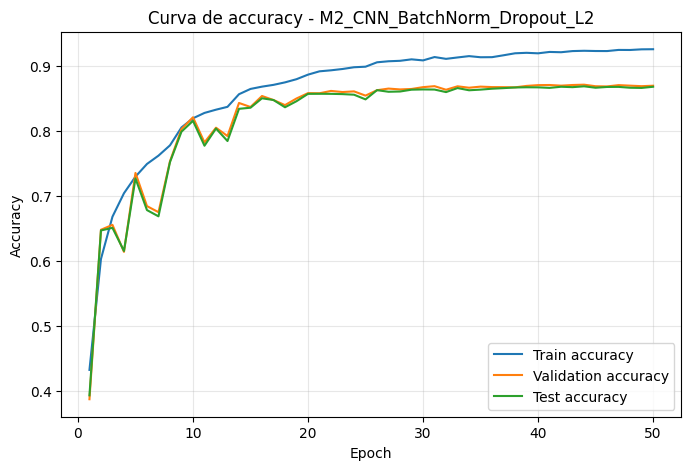

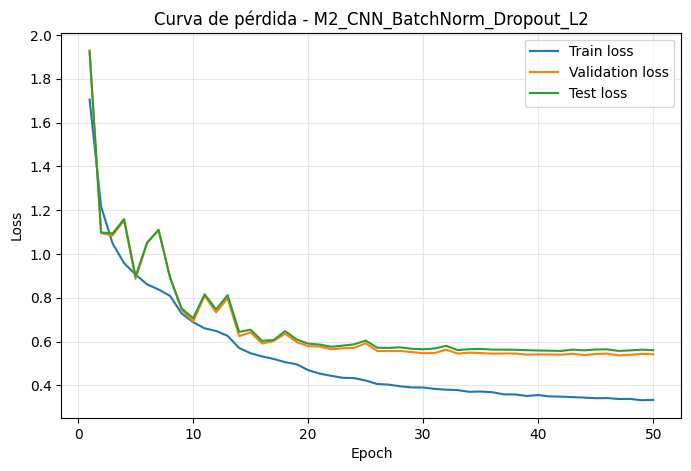

In [ ]:
def build_regularized_cnn():
    weight_decay = 1e-4

    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            32, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(
            32, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),

        layers.Conv2D(
            64, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(
            64, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.30),

        layers.Conv2D(
            128, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(
            128, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.40),

        layers.Flatten(),
        layers.Dense(
            256,
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.50),

        layers.Dense(num_classes, activation="softmax")
    ], name="M2_CNN_BatchNorm_Dropout_L2")

    return model


regularized_cnn = build_regularized_cnn()
regularized_cnn.summary()

regularized_cnn, regularized_cnn_history, regularized_cnn_pred = run_experiment(
    model_name="M2_CNN_BatchNorm_Dropout_L2",
    build_model_fn=build_regularized_cnn
)

plot_training_curves("M2_CNN_BatchNorm_Dropout_L2")

### Análisis del modelo M2. CNN con Batch Normalization, Dropout y L2

El modelo M2 introduce varias técnicas de regularización y estabilización del entrenamiento sobre la CNN simple. En concreto, se añaden capas de Batch Normalization, Dropout progresivo y regularización L2 en las capas convolucionales y densas.

El resultado mejora de forma clara respecto al modelo M1. La accuracy en test pasa de aproximadamente 74.91 % a 86.78 %, y el F1 macro alcanza 0.8667. El modelo mejora la accuracy global y además mantiene un rendimiento equilibrado entre las distintas clases del dataset.

Las curvas de entrenamiento muestran un comportamiento mucho más estable que en la CNN simple. Aunque la accuracy de entrenamiento sigue siendo ligeramente superior a la de validación y test, la diferencia es pequeña. La pérdida de validación se mantiene estable y baja, sin el incremento claro observado en M1. Esto sugiere que Batch Normalization, Dropout y L2 han reducido significativamente el sobreajuste que era el objetivo.

Como parte negativa, el coste computacional aumenta ya que el modelo tiene más capas y tarda bastante más en entrenarse. Aun así, la mejora de rendimiento justifica esta arquitectura como una candidata perfecta para el modelo final a falta de siguiente modelos de prueba.